In [1]:
import cv2
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def processar_video(caminho_video):
    # 1. Carregar o Vídeo
    cap = cv2.VideoCapture(caminho_video)
    
    if not cap.isOpened():
        print("Erro: Não foi possível abrir o vídeo.")
        return

    # Obter FPS (Frames por Segundo) para calcular o tempo corretamente
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Vídeo carregado. FPS detectado: {fps}")

    # 2. Configurar o Rastreador (Tracker)
    # Usamos o CSRT que é robusto, mas um pouco mais lento. Ótimo para precisão.
    tracker = cv2.TrackerCSRT_create()

    # Ler o primeiro frame
    ret, frame = cap.read()
    if not ret:
        print("Erro ao ler o primeiro frame.")
        return

    print("PASSO 1: Desenhe um retângulo à volta da bolinha preta e pressione ENTER ou ESPAÇO.")
    # Abre uma janela para você selecionar a bolinha manualmente
    roi = cv2.selectROI("Selecione o Marcador", frame, fromCenter=False, showCrosshair=True)
    tracker.init(frame, roi)
    cv2.destroyWindow("Selecione o Marcador")

    # Listas para guardar os dados brutos
    dados_y = []
    frames = []
    frame_count = 0

    print("A processar vídeo... (Pressione 'q' para interromper)")

    # 3. Loop de Processamento (Frame a Frame)
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Atualizar o rastreador
        sucesso, box = tracker.update(frame)

        if sucesso:
            # A box retorna (x, y, largura, altura)
            x, y, w, h = [int(v) for v in box]
            
            # Calculamos o centro da bolinha
            centro_y = y + h // 2
            centro_x = x + w // 2

            # Guardamos apenas a posição Y (que é a vibração principal da régua)
            dados_y.append(centro_y)
            frames.append(frame_count)

            # Desenhar na tela para você ver a acontecer
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.circle(frame, (centro_x, centro_y), 3, (0, 0, 255), -1)
        
        cv2.imshow("Rastreamento em Tempo Real", frame)
        
        # Pressione 'q' para sair mais cedo
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
        frame_count += 1

    cap.release()
    cv2.destroyAllWindows()

    # 4. Análise de Dados com POLARS
    print("A gerar gráficos com Polars...")
    
    # Criar DataFrame
    df = pl.DataFrame({
        "frame": frames,
        "pixel_y": dados_y
    })

    # Criar coluna de Tempo (segundos)
    df = df.with_columns(
        (pl.col("frame") / fps).alias("tempo_s")
    )

    # Remover a média (DC offset) para a vibração oscilar em torno de zero
    media_y = df["pixel_y"].mean()
    df = df.with_columns(
        (pl.col("pixel_y") - media_y).alias("amplitude")
    )

    # 5. Calcular a FFT (Transformada de Fourier) usando NumPy
    sinal = df["amplitude"].to_numpy()
    n = len(sinal)
    
    # FFT
    fft_vals = np.fft.fft(sinal)
    fft_freqs = np.fft.fftfreq(n, d=1/fps)

    # Pegar apenas a metade positiva do espectro
    metade_n = n // 2
    frequencias = fft_freqs[:metade_n]
    amplitudes = np.abs(fft_vals)[:metade_n]

    # 6. Plotar Resultados
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # Gráfico 1: Domínio do Tempo (O que a câmera viu)
    ax1.plot(df["tempo_s"], df["amplitude"], color='blue')
    ax1.set_title("Vibração no Domínio do Tempo")
    ax1.set_xlabel("Tempo (s)")
    ax1.set_ylabel("Deslocamento (pixels)")
    ax1.grid(True)

    # Gráfico 2: Domínio da Frequência (O que a física diz)
    ax2.plot(frequencias, amplitudes, color='red')
    ax2.set_title("Espectro de Frequência (FFT)")
    ax2.set_xlabel("Frequência (Hz)")
    ax2.set_ylabel("Magnitude")
    ax2.set_xlim(0, 30) # Limitamos a 30Hz pois é o foco da sua Nikon/Régua
    ax2.grid(True)
    
    # Encontrar o pico máximo
    pico_idx = np.argmax(amplitudes)
    freq_pico = frequencias[pico_idx]
    ax2.annotate(f'Pico: {freq_pico:.2f} Hz', 
                 xy=(freq_pico, amplitudes[pico_idx]), 
                 xytext=(freq_pico+2, amplitudes[pico_idx]),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.tight_layout()
    plt.show()

In [ ]:
# --- COMO USAR ---
# Substitua pelo nome do seu vídeo gravado
# Se o vídeo estiver na mesma pasta, basta o nome.
arquivo_video = "teste_regua.mp4" 

# Tente processar (certifique-se que o arquivo existe)
try:
    processar_video(arquivo_video)
except Exception as e:
    print(f"Ocorreu um erro. Verifique se o nome do vídeo está correto.\nErro: {e}")

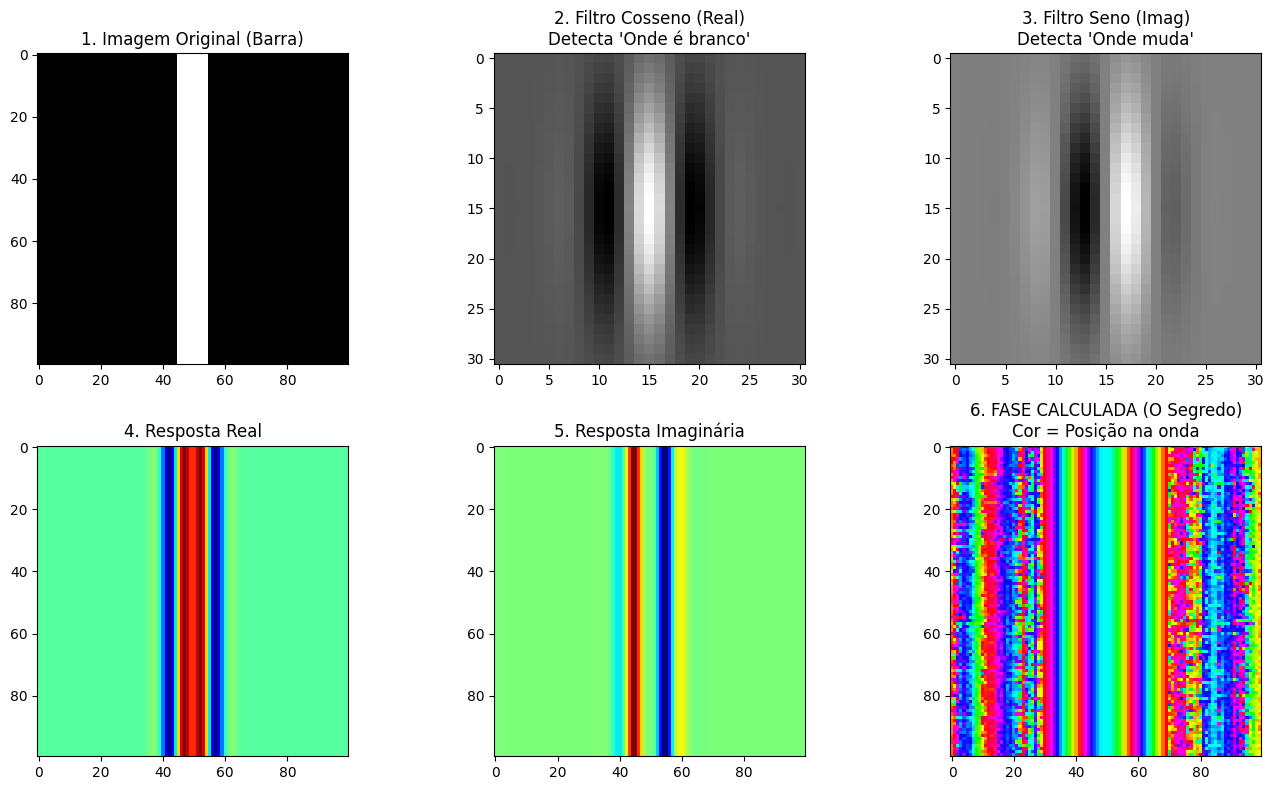

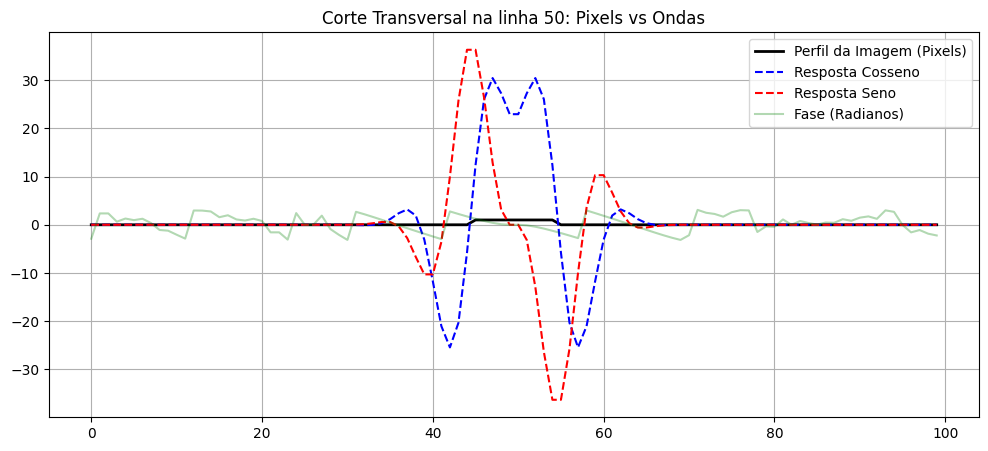

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualizar_ondas_gabor():
    # 1. CRIAR UMA IMAGEM SINTÉTICA (Simples)
    # 100x100 pixels, fundo preto (0)
    img = np.zeros((100, 100), dtype=np.float32)
    # Desenhamos uma barra branca (valor 1.0) no meio. Essa é a nossa "borda"
    img[:, 45:55] = 1.0

    # 2. CRIAR OS FILTROS DE GABOR (Os "Moldes" de Onda)
    # Parâmetros do filtro
    ksize = 31       # Tamanho do filtro (31x31 pixels)
    sigma = 4.0      # Desvio padrão da Gaussiana (largura do envelope)
    theta = 0        # Orientação: 0 = Vertical (para pegar nossa barra vertical)
    lambd = 10.0     # Comprimento da onda (wavelength) em pixels
    gamma = 0.5      # Aspect ratio espacial
    
    # Filtro REAL (Cosseno) - Fase offset (psi) = 0
    # Este filtro procura por intensidade (brilho)
    kernel_real = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
    
    # Filtro IMAGINÁRIO (Seno) - Fase offset (psi) = pi/2
    # Este filtro procura por transições (bordas)
    kernel_imag = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)

    # 3. APLICAR A CONVOLUÇÃO (Passar o filtro na imagem)
    res_real = cv2.filter2D(img, cv2.CV_32F, kernel_real)
    res_imag = cv2.filter2D(img, cv2.CV_32F, kernel_imag)

    # 4. CALCULAR AMPLITUDE E FASE LOCAL
    # Aqui está a mágica da pirâmide complexa simplificada
    amplitude = np.sqrt(res_real**2 + res_imag**2)
    fase = np.arctan2(res_imag, res_real)

    # --- VISUALIZAÇÃO ---
    plt.figure(figsize=(14, 8))

    # A: Imagem Original e Filtros
    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("1. Imagem Original (Barra)")
    
    plt.subplot(2, 3, 2)
    plt.imshow(kernel_real, cmap='gray')
    plt.title("2. Filtro Cosseno (Real)\nDetecta 'Onde é branco'")

    plt.subplot(2, 3, 3)
    plt.imshow(kernel_imag, cmap='gray')
    plt.title("3. Filtro Seno (Imag)\nDetecta 'Onde muda'")

    # B: Respostas dos Filtros
    plt.subplot(2, 3, 4)
    plt.imshow(res_real, cmap='jet')
    plt.title("4. Resposta Real")

    plt.subplot(2, 3, 5)
    plt.imshow(res_imag, cmap='jet')
    plt.title("5. Resposta Imaginária")
    
    plt.subplot(2, 3, 6)
    plt.imshow(fase, cmap='hsv') # HSV é bom para fase cíclica (-pi a pi)
    plt.title("6. FASE CALCULADA (O Segredo)\nCor = Posição na onda")

    plt.tight_layout()
    plt.show()

    # --- GRÁFICO 1D (O CORTA-MATO) ---
    # Vamos pegar uma linha horizontal (pixel 50) e ver os valores como gráfico
    linha = 50
    plt.figure(figsize=(12, 5))
    
    plt.plot(img[linha, :], 'k-', linewidth=2, label='Perfil da Imagem (Pixels)')
    plt.plot(res_real[linha, :], 'b--', label='Resposta Cosseno')
    plt.plot(res_imag[linha, :], 'r--', label='Resposta Seno')
    plt.plot(fase[linha, :], 'g-', alpha=0.3, label='Fase (Radianos)')
    
    plt.title(f"Corte Transversal na linha {linha}: Pixels vs Ondas")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    visualizar_ondas_gabor()

Tentando carregar: Images/logo volvo.png
Linha de análise Horizontal: 64
Analisando Coluna Vertical: 28


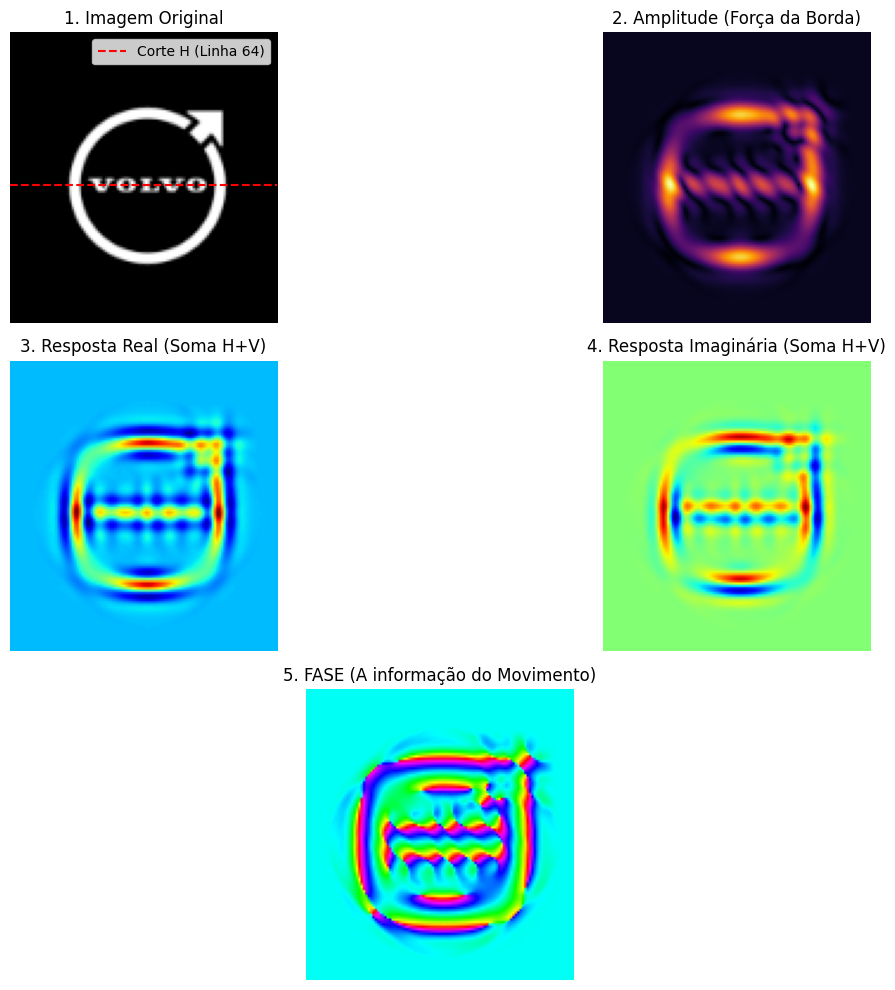

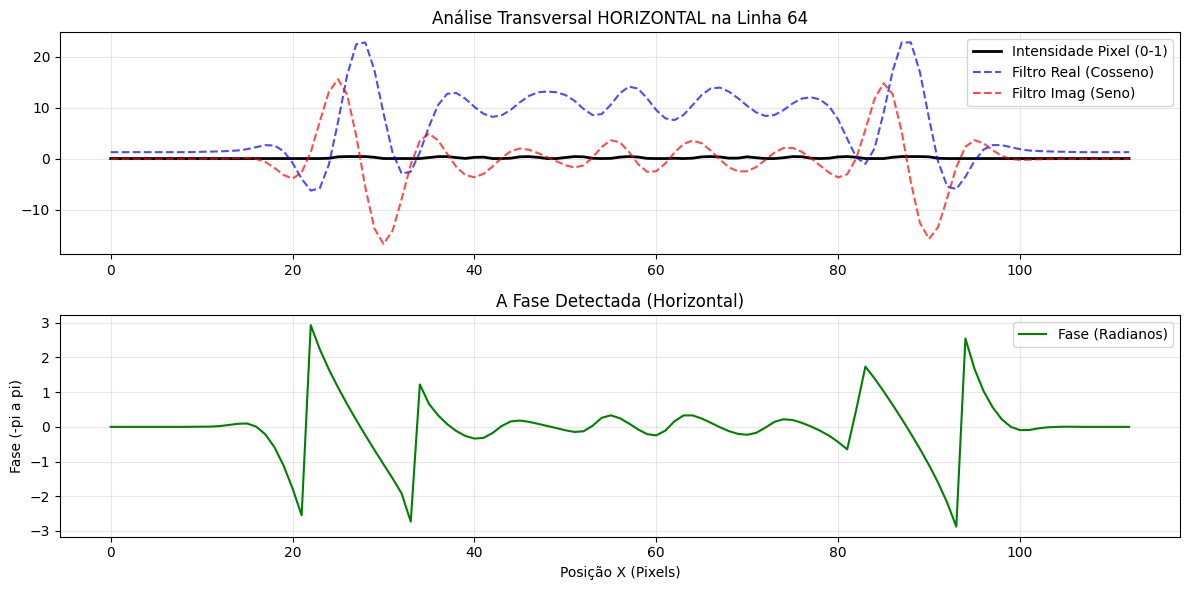

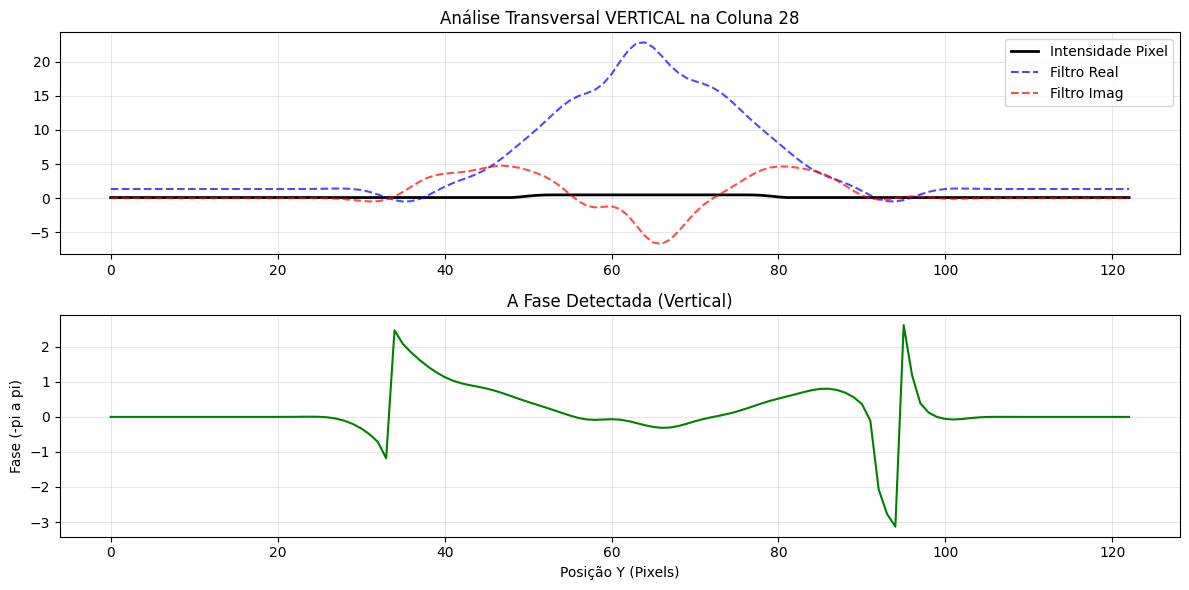

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

# --- CONFIGURAÇÃO ---
# Certifique-se que o arquivo existe na pasta Images
NOME_DA_IMAGEM = "Images/logo volvo.png" 
# --------------------

def visualizar_ondas_gabor_completo(caminho_imagem):
    # 1. CARREGAR E PREPARAR A IMAGEM REAL
    print(f"Tentando carregar: {caminho_imagem}")
    img_raw = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)

    if img_raw is None:
        print(f"\nERRO CRÍTICO: Não foi possível abrir a imagem '{caminho_imagem}'.")
        print("Verifique se o caminho está correto.")
        sys.exit()

    # Converter para float32 (0.0 a 1.0)
    img = img_raw.astype(np.float32) / 255.0

    # Redimensionar se necessário (para não travar o PC com imagens 4K)
    altura, largura = img.shape[:2]
    if largura > 800:
        fator = 800 / largura
        img = cv2.resize(img, (int(largura*fator), int(altura*fator)))
        print(f"Imagem redimensionada para: {img.shape}")
    
    # 2. CRIAR OS FILTROS DE GABOR
    ksize = 31
    sigma = 4.0
    lambd = 10.0
    gamma = 0.5
    
    # --- DIREÇÃO 1: VERTICAL (Theta = 0) ---
    kern_real_v = cv2.getGaborKernel((ksize, ksize), sigma, 0, lambd, gamma, 0, ktype=cv2.CV_32F)
    kern_imag_v = cv2.getGaborKernel((ksize, ksize), sigma, 0, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)
    
    # --- DIREÇÃO 2: HORIZONTAL (Theta = Pi/2) ---
    kern_real_h = cv2.getGaborKernel((ksize, ksize), sigma, np.pi/2, lambd, gamma, 0, ktype=cv2.CV_32F)
    kern_imag_h = cv2.getGaborKernel((ksize, ksize), sigma, np.pi/2, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)

    # Aplicar filtros (Convolução)
    f_real_v = cv2.filter2D(img, cv2.CV_32F, kern_real_v)
    f_imag_v = cv2.filter2D(img, cv2.CV_32F, kern_imag_v)
    f_real_h = cv2.filter2D(img, cv2.CV_32F, kern_real_h)
    f_imag_h = cv2.filter2D(img, cv2.CV_32F, kern_imag_h)

    # SOMAR AS ENERGIAS (Combinar vertical e horizontal)
    # Isso garante que detectamos bordas em qualquer direção
    res_real = f_real_v + f_real_h
    res_imag = f_imag_v + f_imag_h

    # Calcular Amplitude e Fase combinadas
    amplitude = np.sqrt(res_real**2 + res_imag**2)
    fase = np.arctan2(res_imag, res_real)

    # Encontrar o ponto de maior energia para decidir onde cortar
    y_max, x_max = np.unravel_index(np.argmax(amplitude), amplitude.shape)
    linha_corte = y_max # Fixa para 50 ou use y_max para dinâmico
    print(f"Linha de análise Horizontal: {linha_corte}")

    # ==========================================
    # JANELA 1: O GRID DE IMAGENS (VISUALIZAÇÃO)
    # ==========================================
    plt.figure(figsize=(12, 10))

    # 1. Imagem Original com a linha de corte desenhada
    plt.subplot(3, 2, 1)
    img_com_linha = img.copy()
    plt.imshow(img, cmap='gray')
    # Desenha a linha vermelha no plot
    plt.axhline(y=linha_corte, color='r', linestyle='--', label=f'Corte H (Linha {linha_corte})') 
    plt.title(f"1. Imagem Original")
    plt.legend()
    plt.axis('off')

    plt.subplot(3, 2, 2)
    plt.imshow(amplitude, cmap='inferno')
    plt.title("2. Amplitude (Força da Borda)")
    plt.axis('off')

    plt.subplot(3, 2, 3)
    plt.imshow(res_real, cmap='jet')
    plt.title(f"3. Resposta Real (Soma H+V)")
    plt.axis('off')

    plt.subplot(3, 2, 4)
    plt.imshow(res_imag, cmap='jet')
    plt.title(f"4. Resposta Imaginária (Soma H+V)")
    plt.axis('off')
    
    plt.subplot(3, 1, 3)
    plt.imshow(fase, cmap='hsv') 
    plt.title("5. FASE (A informação do Movimento)")
    plt.axis('off')

    plt.tight_layout()

    # ==========================================
    # JANELA 2: GRÁFICO 1D - CORTE HORIZONTAL
    # (Analisa uma LINHA da esquerda para a direita)
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Extrair dados daquela linha específica
    dados_pixel = img[linha_corte, :]
    dados_real = res_real[linha_corte, :]
    dados_imag = res_imag[linha_corte, :]
    dados_fase = fase[linha_corte, :]

    # Plotar Pixels vs Filtros
    plt.subplot(2, 1, 1)
    plt.plot(dados_pixel, 'k-', linewidth=2, label='Intensidade Pixel (0-1)')
    plt.plot(dados_real, 'b--', alpha=0.7, label='Filtro Real (Cosseno)')
    plt.plot(dados_imag, 'r--', alpha=0.7, label='Filtro Imag (Seno)')
    plt.title(f"Análise Transversal HORIZONTAL na Linha {linha_corte}")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Plotar a Fase
    plt.subplot(2, 1, 2)
    plt.plot(dados_fase, 'g-', linewidth=1.5, label='Fase (Radianos)')
    plt.title("A Fase Detectada (Horizontal)")
    plt.ylabel("Fase (-pi a pi)")
    plt.xlabel("Posição X (Pixels)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # ==========================================
    # JANELA 3: GRÁFICO 1D - CORTE VERTICAL
    # (Analisa uma COLUNA de cima para baixo)
    # ==========================================
    
    # Usamos o X máximo encontrado anteriormente
    coluna_corte = x_max # Fixa para 50 ou use x_max para dinâmico 
    print(f"Analisando Coluna Vertical: {coluna_corte}")
    
    plt.figure(figsize=(12, 6))

    # NOTA: O slice agora é [:, coluna_corte] (Todas as linhas, uma coluna)
    dados_pixel_v = img[:, coluna_corte]
    dados_real_v = res_real[:, coluna_corte]
    dados_imag_v = res_imag[:, coluna_corte]
    dados_fase_v = fase[:, coluna_corte]

    # Plotar Pixels vs Filtros
    plt.subplot(2, 1, 1)
    # Eixo X agora representa a altura (Y) da imagem
    plt.plot(dados_pixel_v, 'k-', linewidth=2, label='Intensidade Pixel')
    plt.plot(dados_real_v, 'b--', alpha=0.7, label='Filtro Real')
    plt.plot(dados_imag_v, 'r--', alpha=0.7, label='Filtro Imag')
    plt.title(f"Análise Transversal VERTICAL na Coluna {coluna_corte}")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Plotar a Fase
    plt.subplot(2, 1, 2)
    plt.plot(dados_fase_v, 'g-', linewidth=1.5, label='Fase (Radianos)')
    plt.title("A Fase Detectada (Vertical)")
    plt.ylabel("Fase (-pi a pi)")
    plt.xlabel("Posição Y (Pixels)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    
    plt.show()

if __name__ == "__main__":
    visualizar_ondas_gabor_completo(NOME_DA_IMAGEM)

Tentando carregar: Images/logo volvo.png
Dominante: VERTICAL (Corte na linha 64)


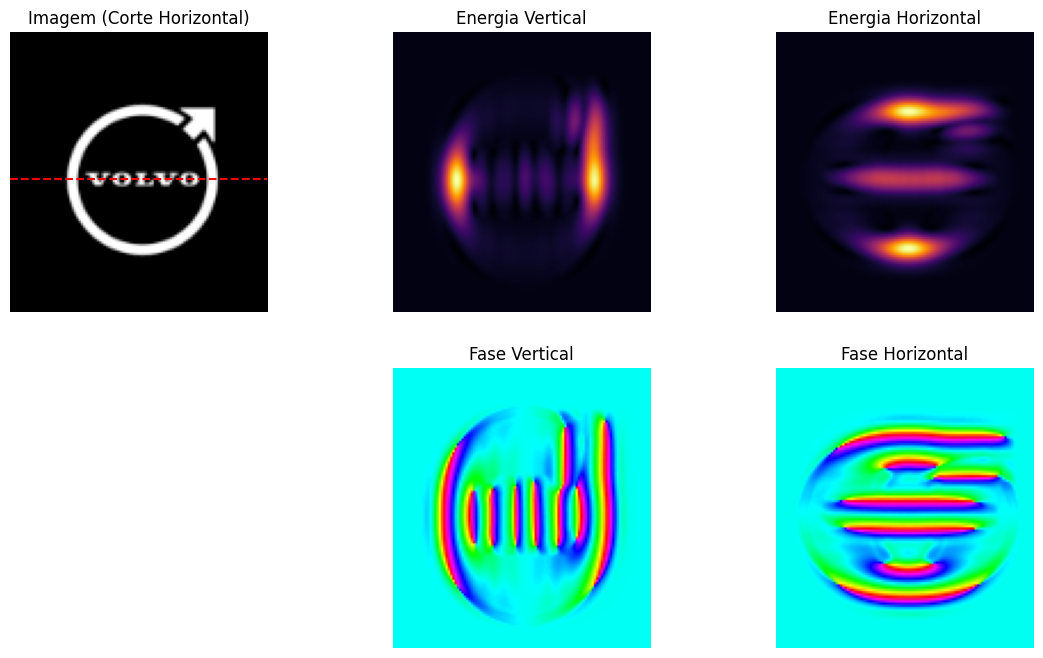

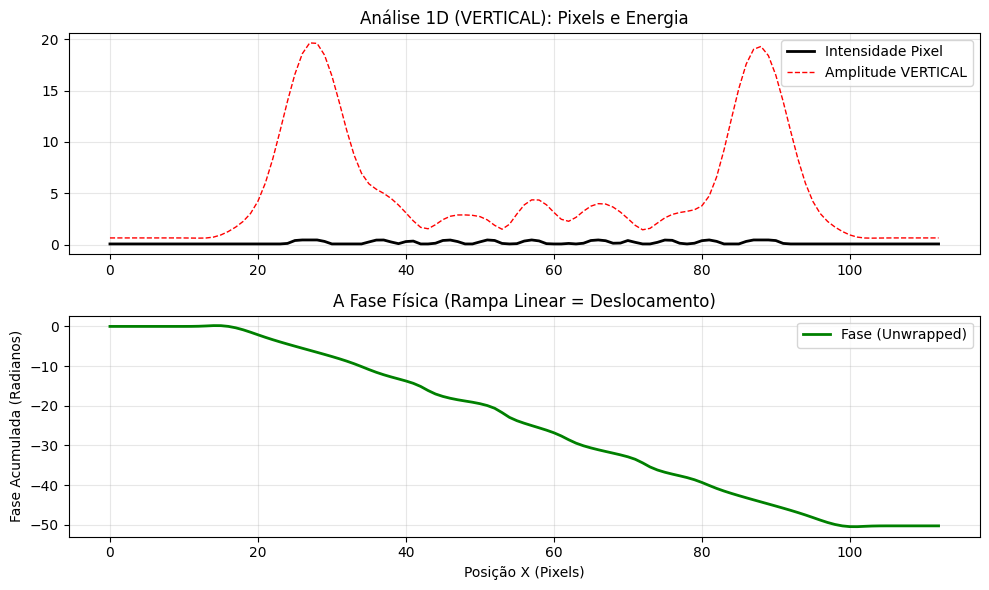

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

# --- CONFIGURAÇÃO ---
NOME_DA_IMAGEM = "Images/logo volvo.png" 
# --------------------

def visualizar_ondas_gabor_correto(caminho_imagem):
    # 1. CARREGAR IMAGEM
    print(f"Tentando carregar: {caminho_imagem}")
    img_raw = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)

    if img_raw is None:
        print(f"ERRO: Não achei a imagem '{caminho_imagem}'.")
        sys.exit()

    img = img_raw.astype(np.float32) / 255.0
    
    # Redimensionar para processamento rápido (opcional)
    altura, largura = img.shape[:2]
    if largura > 800:
        fator = 800 / largura
        img = cv2.resize(img, (int(largura*fator), int(altura*fator)))

    # 2. DEFINIR FILTROS (GABOR)
    ksize = 31
    sigma = 4.0
    lambd = 10.0
    gamma = 0.5
    
    # --- FILTRO VERTICAL (Theta = 0) ---
    # Detecta bordas Verticais (que variam na horizontal)
    kern_real_v = cv2.getGaborKernel((ksize, ksize), sigma, 0, lambd, gamma, 0, ktype=cv2.CV_32F)
    kern_imag_v = cv2.getGaborKernel((ksize, ksize), sigma, 0, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)
    
    # --- FILTRO HORIZONTAL (Theta = Pi/2) ---
    # Detecta bordas Horizontais (que variam na vertical)
    kern_real_h = cv2.getGaborKernel((ksize, ksize), sigma, np.pi/2, lambd, gamma, 0, ktype=cv2.CV_32F)
    kern_imag_h = cv2.getGaborKernel((ksize, ksize), sigma, np.pi/2, lambd, gamma, np.pi/2, ktype=cv2.CV_32F)

    # 3. APLICAR CONVOLUÇÃO (SEPARADO!)
    # Respostas para Vertical
    f_real_v = cv2.filter2D(img, cv2.CV_32F, kern_real_v)
    f_imag_v = cv2.filter2D(img, cv2.CV_32F, kern_imag_v)
    
    # Respostas para Horizontal
    f_real_h = cv2.filter2D(img, cv2.CV_32F, kern_real_h)
    f_imag_h = cv2.filter2D(img, cv2.CV_32F, kern_imag_h)

    # 4. CALCULAR AMPLITUDE E FASE (SEPARADO!)
    # Amplitude e Fase Vertical
    amp_v = np.sqrt(f_real_v**2 + f_imag_v**2)
    fase_v = np.arctan2(f_imag_v, f_real_v)

    # Amplitude e Fase Horizontal
    amp_h = np.sqrt(f_real_h**2 + f_imag_h**2)
    fase_h = np.arctan2(f_imag_h, f_real_h)

    # Para visualização geral, podemos somar AMPlitudes (energia), mas NUNCA as fases
    amp_total = amp_v + amp_h

    # 5. LÓGICA DE CORTE INTELIGENTE
    # Vamos achar o ponto mais forte da imagem
    y_max, x_max = np.unravel_index(np.argmax(amp_total), amp_total.shape)
    
    # Decidir qual direção domina nesse ponto
    forca_v = amp_v[y_max, x_max]
    forca_h = amp_h[y_max, x_max]

    if forca_v > forca_h:
        print(f"Dominante: VERTICAL (Corte na linha {y_max})")
        modo = "VERTICAL"
        # Se é vertical, cortamos uma linha horizontal para ver a variação
        dados_pixel = img[y_max, :]
        dados_fase = fase_v[y_max, :] # Usamos a fase V
        dados_amp = amp_v[y_max, :]
        eixo_label = "Posição X (Pixels)"
        corte_idx = y_max
        tipo_corte = "Horizontal" # O corte atravessa a borda vertical
    else:
        print(f"Dominante: HORIZONTAL (Corte na coluna {x_max})")
        modo = "HORIZONTAL"
        # Se é horizontal, cortamos uma coluna vertical para ver a variação
        dados_pixel = img[:, x_max]
        dados_fase = fase_h[:, x_max] # Usamos a fase H
        dados_amp = amp_h[:, x_max]
        eixo_label = "Posição Y (Pixels)"
        corte_idx = x_max
        tipo_corte = "Vertical"

    # Sugestão da análise: Unwrap na fase para o gráfico ficar bonito
    dados_fase_unwrap = np.unwrap(dados_fase)

    # ================= GRAFICSO ==================



    plt.figure(figsize=(14, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap='gray')
    if modo == "VERTICAL":
        plt.axhline(y=corte_idx, color='r', linestyle='--')
    else:
        plt.axvline(x=corte_idx, color='r', linestyle='--')
    plt.title(f"Imagem (Corte {tipo_corte})")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(amp_v, cmap='inferno')
    plt.title("Energia Vertical")
    plt.axis('off')

    # ================= GRAFICO 1==================
    plt.subplot(2, 3, 3)
    plt.imshow(amp_h, cmap='inferno')
    plt.title("Energia Horizontal")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(fase_v, cmap='hsv')
    plt.title("Fase Vertical")
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(fase_h, cmap='hsv')
    plt.title("Fase Horizontal")
    plt.axis('off')

    plt.figure(figsize=(10, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(dados_pixel, 'k-', lw=2, label='Intensidade Pixel')
    plt.plot(dados_amp, 'r--', lw=1, label=f'Amplitude {modo}')
    plt.title(f"Análise 1D ({modo}): Pixels e Energia")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.plot(dados_fase_unwrap, 'g-', lw=2, label='Fase (Unwrapped)')
    plt.title("A Fase Física (Rampa Linear = Deslocamento)")
    plt.ylabel("Fase Acumulada (Radianos)")
    plt.xlabel(eixo_label)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualizar_ondas_gabor_correto(NOME_DA_IMAGEM)

In [1]:
import cv2 as cv
img = cv.imread("Images/logo volvo.png")
cv.imshow("Image", img)
cv.waitKey(0)


-1

In [ ]:
import cv2 as cv

capture = cv.VideoCapture('videos/video.mp4')

while True:
    isTrue, frame = capture.read()

    # Adicione esta verificação de segurança
    if not isTrue:
        print("Fim do vídeo ou arquivo não encontrado.")
        break

    cv.imshow('Video', frame)

    if cv.waitKey(20) & 0xFF==ord('d'):
        break

capture.release()
cv.destroyAllWindows()

Fim do vídeo ou arquivo não encontrado.
